In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

First, let's load the `HR_comma_sep.csv` file into a pandas DataFrame and display its first few rows and basic information.

In [2]:
df = pd.read_csv('/content/HR_comma_sep.csv')
display(df.head())
display(df.info())

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


None

## Exploratory Data Analysis (EDA)

Let's analyze which variables impact employee retention. The target variable `left` indicates whether an employee left the company (1) or stayed (0).

### Impact of Employee Salaries on Retention

We'll calculate the retention rate (or rather, the attrition rate) for each salary level and visualize it with a bar chart.

/tmp/ipykernel_5299/4138828421.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='salary', y='retention_rate', data=salary_attrition.sort_values('retention_rate', ascending=False), palette='viridis')


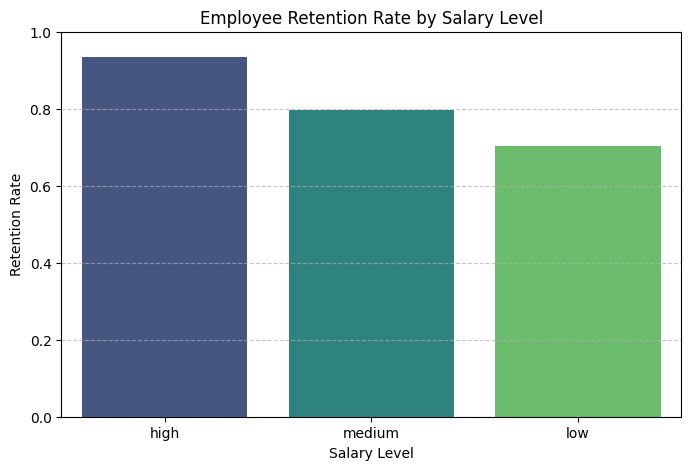

In [3]:

salary_attrition = df.groupby('salary')['left'].mean().reset_index()
salary_attrition['retention_rate'] = 1 - salary_attrition['left']

plt.figure(figsize=(8, 5))
sns.barplot(x='salary', y='retention_rate', data=salary_attrition.sort_values('retention_rate', ascending=False), palette='viridis')
plt.title('Employee Retention Rate by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Retention Rate')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Correlation Between Department and Employee Retention

Next, let's examine the retention rates across different departments.

/tmp/ipykernel_5299/1673710988.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Department', y='retention_rate', data=department_attrition.sort_values('retention_rate', ascending=False), palette='magma')


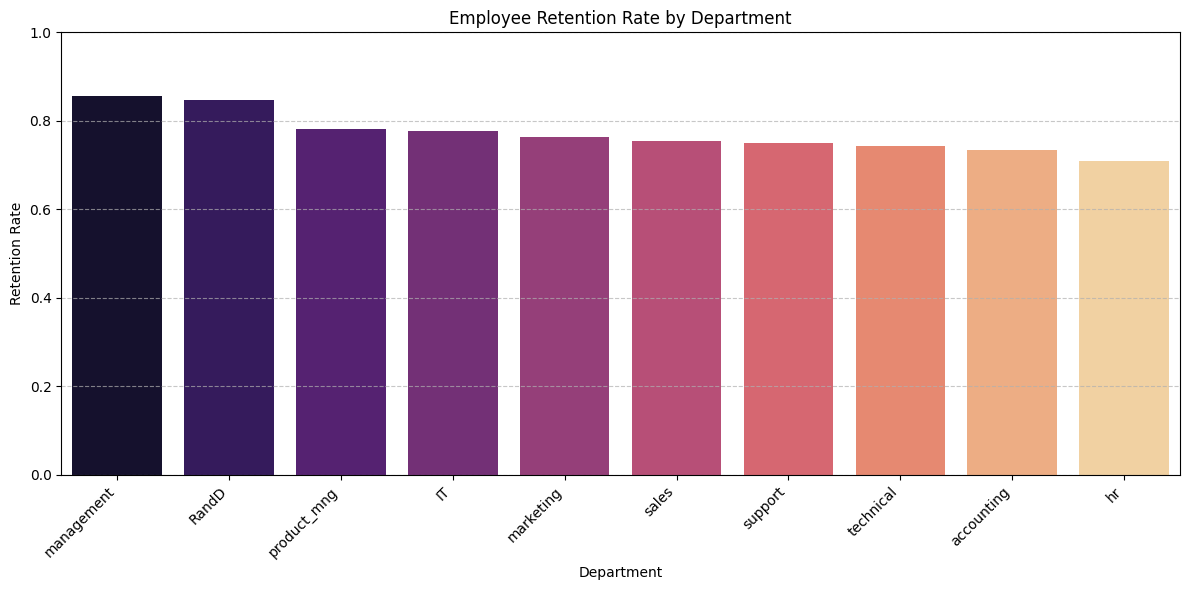

In [5]:

department_attrition = df.groupby('Department')['left'].mean().reset_index()
department_attrition['retention_rate'] = 1 - department_attrition['left']

plt.figure(figsize=(12, 6))
sns.barplot(x='Department', y='retention_rate', data=department_attrition.sort_values('retention_rate', ascending=False), palette='magma')
plt.title('Employee Retention Rate by Department')
plt.xlabel('Department')
plt.ylabel('Retention Rate')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Prepare Data for Logistic Regression

Based on the EDA, `salary` and `Department` show a clear impact on employee retention. We will also include other relevant numerical features from the dataset. First, we need to convert categorical features into numerical ones using one-hot encoding.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


X = df[['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours',
        'time_spend_company', 'Work_accident', 'promotion_last_5years', 'Department', 'salary']]
y = df['left']

X = pd.get_dummies(X, columns=['Department', 'salary'], drop_first=True)

display(X.head())
display(X.info())

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,0,False,False,False,False,False,False,True,False,False,True,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   satisfaction_level      14999 non-null  float64
 1   last_evaluation         14999 non-null  float64
 2   number_project          14999 non-null  int64  
 3   average_montly_hours    14999 non-null  int64  
 4   time_spend_company      14999 non-null  int64  
 5   Work_accident           14999 non-null  int64  
 6   promotion_last_5years   14999 non-null  int64  
 7   Department_RandD        14999 non-null  bool   
 8   Department_accounting   14999 non-null  bool   
 9   Department_hr           14999 non-null  bool   
 10  Department_management   14999 non-null  bool   
 11  Department_marketing    14999 non-null  bool   
 12  Department_product_mng  14999 non-null  bool   
 13  Department_sales        14999 non-null  bool   
 14  Department_support      14999 non-null

None

## Build and Evaluate Logistic Regression Model

Now, we will split the data into training and testing sets, train a logistic regression model, and then evaluate its accuracy.

In [7]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(solver='liblinear', max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.7831
